# FlexTok rFID Evaluation with DreamSim

This notebook evaluates and compares reconstruction quality across different FlexTok models with varying FSQ levels and token counts using the DreamSim perceptual similarity metric.

In [1]:
# Switch path to root of project
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import torch
import torchvision.transforms.functional as TF
from torchvision import transforms
from scipy import linalg

from dreamsim import dreamsim

from flextok.flextok_wrapper import FlexTokFromHub
from flextok.regularizers.quantize_fsq import FSQ
from flextok.model.postprocessors.heads import LinearHead
from flextok.model.preprocessors.linear import LinearLayer
from flextok.utils.dataloader import CelebADataset, CelebAHQDataset, create_celeb_dataloader
from flextok.utils.demo import denormalize, batch_to_pil
from flextok.utils.misc import detect_bf16_support, get_bf16_context, get_generator

# Enable TF32
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Global no_grad
torch.set_grad_enabled(False)

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# Detect if bf16 is enabled
enable_bf16 = detect_bf16_support()
print('BF16 enabled:', enable_bf16)

Device: cuda
BF16 enabled: True


/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## Load DreamSim Model

In [3]:
# Load DreamSim model
print("Loading DreamSim model...")
dreamsim_model, dreamsim_preprocess = dreamsim(pretrained=True, device=device)
print("DreamSim model loaded successfully!")

Using cache found in ./models/facebookresearch_dino_main


Loading DreamSim model...
Using cached ./models


/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


DreamSim model loaded successfully!


/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## Load Dataset

In [17]:
# load dataset
IMG_SIZE = 256
BATCH_SIZE = 32
DATASET_PATH = "./data/celeba/"
NUM_EVAL_SAMPLES = 128

# test dataset
val_dataset = CelebADataset(
    root_dir=DATASET_PATH,
    img_size=IMG_SIZE,
    split="val",
)

print(f"Val dataset: {len(val_dataset)} images")

# Create dataloader
val_dataloader = create_celeb_dataloader(
    dataset_type="celebahq",
    root_dir=DATASET_PATH,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
)

Val dataset: 19866 images


## DreamSim Similarity Computation

DreamSim provides a perceptual similarity metric where lower values indicate more similar images.

In [5]:
def compute_dreamsim_score(original_imgs, reconstructed_imgs, dreamsim_model, dreamsim_preprocess):
    """
    Compute average DreamSim distance between original and reconstructed images.
    
    Args:
        original_imgs: Tensor of shape [B, 3, H, W] in range [-1, 1]
        reconstructed_imgs: Tensor of shape [B, 3, H, W] in range [-1, 1]
        dreamsim_model: DreamSim model
        dreamsim_preprocess: DreamSim preprocessing function
    
    Returns:
        Average DreamSim distance
    """
    # Convert from [-1, 1] to [0, 1]
    original_imgs = (original_imgs + 1) / 2
    reconstructed_imgs = (reconstructed_imgs + 1) / 2
    
    # Clamp to [0, 1]
    original_imgs = original_imgs.clamp(0, 1)
    reconstructed_imgs = reconstructed_imgs.clamp(0, 1)
    
    # Resize to 224x224 for DreamSim
    original_imgs = torch.nn.functional.interpolate(
        original_imgs, size=(224, 224), mode='bilinear', align_corners=False
    )
    reconstructed_imgs = torch.nn.functional.interpolate(
        reconstructed_imgs, size=(224, 224), mode='bilinear', align_corners=False
    )
    
    # Compute DreamSim distance
    with torch.no_grad():
        distance = dreamsim_model(original_imgs, reconstructed_imgs)
    
    # Return mean distance
    return distance.mean().item()

## FID Computation Utilities

We'll also compute FID scores using InceptionV3 for comparison.

In [12]:
from torchvision.models import inception_v3, Inception_V3_Weights
import torch.nn.functional as F

class InceptionV3FeatureExtractor:
    """Extract features from InceptionV3 for FID computation."""
    def __init__(self, device='cuda'):
        self.device = device
        # Load pretrained InceptionV3
        self.model = inception_v3(
            weights=Inception_V3_Weights.DEFAULT,
            transform_input=False
        )
        self.model.fc = torch.nn.Identity()  # Remove final layer
        self.model = self.model.to(device).eval()
        
    def preprocess(self, images):
        """Preprocess images for InceptionV3.
        Args:
            images: Tensor of shape [B, 3, H, W] in range [-1, 1]
        """
        # Convert from [-1, 1] to [0, 1]
        images = (images + 1) / 2
        # Resize to 299x299 for InceptionV3
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        # Normalize using ImageNet stats
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(images.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(images.device)
        images = (images - mean) / std
        return images
    
    @torch.no_grad()
    def extract_features(self, images):
        """Extract InceptionV3 features."""
        images = self.preprocess(images)
        features = self.model(images)
        return features.cpu().numpy()

def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Calculate Frechet Distance between two Gaussian distributions."""
    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)
    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)
    
    diff = mu1 - mu2
    
    # Product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = f"fid calculation produces singular product; adding {eps} to diagonal of cov estimates"
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    
    # Numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError(f"Imaginary component {m}")
        covmean = covmean.real
    
    tr_covmean = np.trace(covmean)
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

def compute_statistics(features):
    """Compute mean and covariance of features."""
    mu = np.mean(features, axis=0)
    sigma = np.cov(features, rowvar=False)
    return mu, sigma

def compute_fid(real_features, fake_features):
    """Compute FID score between real and fake features."""
    mu1, sigma1 = compute_statistics(real_features)
    mu2, sigma2 = compute_statistics(fake_features)
    fid = calculate_frechet_distance(mu1, sigma1, mu2, sigma2)
    return fid

## Model Configuration

Define the models to evaluate and their configurations.

In [9]:
# Model configurations
models_config = [
    {
        'name': 'FSQ-2',
        'ckpt_path': '/home/iyu/ml-flextok/checkpoints/celeba_d18_fsq_2/20251130/checkpoint_best.pt',
        'fsq_levels': [2],
        'color': '#FFA07A',  # Light salmon
        'marker': 'o'
    },
    {
        'name': 'FSQ-4',
        'ckpt_path': '/home/iyu/ml-flextok/checkpoints/celeba_d18_fsq_4/20251202/checkpoint_best.pt',
        'fsq_levels': [4],
        'color': '#FF6347',  # Tomato red
        'marker': 's'
    },
    {
        'name': 'FSQ-8',
        'ckpt_path': '/home/iyu/ml-flextok/checkpoints/celeba_d18_fsq_8/20251202/checkpoint_best.pt',
        'fsq_levels': [8],
        'color': '#DC143C',  # Crimson
        'marker': '^'
    },
    {
        'name': 'Original FSQ',
        'ckpt_path': None,
        'fsq_levels': None,  # Use original FSQ levels
        'color': '#8B0000',  # Dark red
        'marker': 'D'
    },
]

# Token counts to evaluate
token_counts = [1, 2, 4, 8, 16, 32, 64, 128, 256]

## Model Loading Helper Function

In [10]:
def load_flextok_model(ckpt_path, new_levels=None, device='cuda'):
    """Load FlexTok model with optional FSQ level adjustment.
    
    Args:
        ckpt_path: Path to checkpoint file
        new_levels: New FSQ levels (list) or None to keep original
        device: Device to load model on
    
    Returns:
        Loaded FlexTok model
    """
    # Load base model from HuggingFace
    flextok = FlexTokFromHub.from_pretrained('EPFL-VILAB/flextok_d18_d18_in1k').to(device).eval()
    
    if new_levels is not None:
        # Get the original FSQ configuration
        old_fsq: FSQ = flextok.regularizer
        
        # Check if the encoder output dimension matches the fsq levels length
        old_fsq_output_dim = old_fsq.dim
        if old_fsq_output_dim != len(new_levels):
            # Project encoder dim to new fsq dim
            print(f"Adjusting encoder output dimension from {old_fsq_output_dim} to {len(new_levels)}")
            new_enc_linear_head = LinearHead(
                read_key=flextok.encoder.module_dict["enc_to_latents"].read_key,
                write_key=flextok.encoder.module_dict["enc_to_latents"].write_key,
                dim=flextok.encoder.module_dict["enc_to_latents"].dim_in,
                dim_out=len(new_levels),
                use_mup_readout=False,
            )
            flextok.encoder.module_dict['enc_to_latents'] = new_enc_linear_head
            
            # Project back from fsq to decoder input dim
            print(f"Adjusting decoder input dimension to {len(new_levels)}")
            new_dec_linear_head = LinearLayer(
                read_key=flextok.decoder.module_dict["dec_from_latents"].read_key,
                write_key=flextok.decoder.module_dict["dec_from_latents"].write_key,
                dim_in=len(new_levels),
                dim=flextok.decoder.module_dict["dec_from_latents"].dim_out,
            )
            flextok.decoder.module_dict['dec_from_latents'] = new_dec_linear_head
        
        # Create new FSQ with modified levels
        new_fsq = FSQ(
            latents_read_key=old_fsq.latents_read_key,
            quants_write_key=old_fsq.quants_write_key,
            tokens_write_key=old_fsq.tokens_write_key,
            levels=new_levels,
            drop_quant_p=old_fsq.drop_quant_p,
            corrupt_tokens_p=old_fsq.corrupt_tokens_p,
            min_corrupt_tokens_p=old_fsq.min_corrupt_tokens_p,
            apply_corrupt_tokens_p=old_fsq.apply_corrupt_tokens_p,
            packed_call=old_fsq.packed_call,
        )
        
        # Replace the FSQ module
        flextok.regularizer = new_fsq
    
    # Load checkpoint
    if ckpt_path is not None:
        print(f"Loading checkpoint from {ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
        flextok.load_state_dict(checkpoint['model_state_dict'])
    flextok = flextok.to(device).eval()
    
    return flextok

## Extract Real Image Features

Extract features from real images to use as reference for FID computation.

In [19]:
# Initialize feature extractor
feature_extractor = InceptionV3FeatureExtractor(device=device)

# Extract features from real images
print("Extracting features from real images...")
real_features_list = []
num_batches = min(NUM_EVAL_SAMPLES // BATCH_SIZE, len(val_dataloader))

for i, batch in enumerate(tqdm(val_dataloader, total=num_batches, desc="Real images")):
    if i >= num_batches:
        break
    
    imgs = batch.to(device)
    features = feature_extractor.extract_features(imgs)
    real_features_list.append(features)

real_features = np.concatenate(real_features_list, axis=0)
print(f"Extracted features from {real_features.shape[0]} real images")
print(f"Feature shape: {real_features.shape}")

Extracting features from real images...


Real images: 100%|██████████| 4/4 [00:01<00:00,  3.34it/s]

Extracted features from 128 real images
Feature shape: (128, 2048)


## Evaluate Models and Compute Metrics

Evaluate each model across different token counts and compute both rFID and DreamSim scores.

In [20]:
rfid_results = {model['name']: {k: [] for k in token_counts} for model in models_config}
dreamsim_results = {model['name']: {k: [] for k in token_counts} for model in models_config}

# Evaluation parameters
TIMESTEPS = 25
GUIDANCE_SCALE = 7.5
PERFORM_NORM_GUIDANCE = True
SEED = 42

for model_config in models_config:
    print(f"\n{'='*80}")
    print(f"Evaluating model: {model_config['name']}")
    print(f"{'='*80}")
    
    # Load model
    flextok = load_flextok_model(
        ckpt_path=model_config['ckpt_path'],
        new_levels=model_config['fsq_levels'],
        device=device
    )
    
    # Evaluate for each token count
    for k_tokens in token_counts:
        print(f"\nEvaluating with {k_tokens} tokens...")
        
        fake_features_list = []
        dreamsim_scores = []
        
        # Reset dataloader
        val_iter = iter(val_dataloader)
        
        for i in tqdm(range(num_batches), desc=f"{k_tokens} tokens"):
            try:
                batch = next(val_iter)
            except StopIteration:
                break
            
            imgs = batch.to(device)
            
            with get_bf16_context(enable_bf16):
                # Tokenize
                tokens_list = flextok.tokenize(imgs)
                
                # Truncate to k_tokens
                truncated_tokens = [seq[:, :k_tokens].clone() for seq in tokens_list]
                
                # Detokenize
                generator = get_generator(seed=SEED, device=device)
                reconst = flextok.detokenize(
                    truncated_tokens,
                    timesteps=TIMESTEPS,
                    guidance_scale=GUIDANCE_SCALE,
                    perform_norm_guidance=PERFORM_NORM_GUIDANCE,
                    generator=generator,
                    verbose=False,
                )
            
            # Extract features from reconstructions for FID
            features = feature_extractor.extract_features(reconst)
            fake_features_list.append(features)
            
            # Compute DreamSim score
            dreamsim_score = compute_dreamsim_score(
                imgs, reconst, dreamsim_model, dreamsim_preprocess
            )
            dreamsim_scores.append(dreamsim_score)
        
        # Compute rFID
        fake_features = np.concatenate(fake_features_list, axis=0)
        fid_score = compute_fid(real_features, fake_features)
        
        # Average DreamSim score
        avg_dreamsim_score = np.mean(dreamsim_scores)
        
        rfid_results[model_config['name']][k_tokens] = fid_score
        dreamsim_results[model_config['name']][k_tokens] = avg_dreamsim_score
        
        print(f"rFID for {k_tokens} tokens: {fid_score:.4f}")
        print(f"DreamSim for {k_tokens} tokens: {avg_dreamsim_score:.4f}")
    
    # Clean up GPU memory
    del flextok
    torch.cuda.empty_cache()

print("\n" + "="*80)
print("Evaluation complete!")
print("="*80)


Evaluating model: FSQ-2
Adjusting encoder output dimension from 6 to 1
Adjusting decoder input dimension to 1
Loading checkpoint from /home/iyu/ml-flextok/checkpoints/celeba_d18_fsq_2/20251130/checkpoint_best.pt

Evaluating with 1 tokens...


1 tokens: 100%|██████████| 4/4 [00:31<00:00,  7.85s/it]


rFID for 1 tokens: 92.9112
DreamSim for 1 tokens: 0.5197

Evaluating with 2 tokens...


2 tokens: 100%|██████████| 4/4 [00:31<00:00,  7.82s/it]


rFID for 2 tokens: 83.9045
DreamSim for 2 tokens: 0.5217

Evaluating with 4 tokens...


...

rFID for 64 tokens: 419.1815
DreamSim for 64 tokens: 0.8586

Evaluating with 128 tokens...


128 tokens: 100%|██████████| 4/4 [00:31<00:00,  7.86s/it]


rFID for 128 tokens: 439.6411
DreamSim for 128 tokens: 0.8532

Evaluating with 256 tokens...


256 tokens: 100%|██████████| 4/4 [00:31<00:00,  7.89s/it]


rFID for 256 tokens: 470.4485
DreamSim for 256 tokens: 0.8614

Evaluation complete!


## Visualize Results

Create plots similar to the reference image showing rFID and DreamSim scores across token counts.

In [21]:
# Print results table - rFID
if 'Original FSQ' in rfid_results and 'd28' in rfid_results:
    del rfid_results['d28']
if 'Original FSQ' in dreamsim_results and 'd28' in dreamsim_results:
    del dreamsim_results['d28']
    
print("\nrFID Results:")
print("=" * 100)
header = "Model" + "".join([f"{k:>10}" for k in token_counts])
print(header)
print("=" * 100)

for model_config in models_config:
    model_name = model_config['name']
    row = f"{model_name:<15}"
    for k in token_counts:
        row += f"{rfid_results[model_name][k]:>10.4f}"
    print(row)

print("=" * 100)

# Print results table - DreamSim
print("\nDreamSim Results:")
print("=" * 100)
print(header)
print("=" * 100)

for model_config in models_config:
    model_name = model_config['name']
    row = f"{model_name:<15}"
    for k in token_counts:
        row += f"{dreamsim_results[model_name][k]:>10.4f}"
    print(row)

print("=" * 100)


rFID Results:
Model         1         2         4         8        16        32        64       128       256
FSQ-2             92.9112   83.9045   74.8079   70.4011   70.2849   72.4580   68.2349   70.8793   75.0555
FSQ-4             82.2575   78.2344   76.8419   73.4322   71.8073   74.7523   72.6389   71.5875   68.4132
FSQ-8             79.2454   76.7479   73.9729   72.8603   67.5954   67.3509   66.8583   62.9512   62.5873
Original FSQ     406.1883  407.6631  376.4964  375.5199  386.4196  403.5686  419.1815  439.6411  470.4485

DreamSim Results:
Model         1         2         4         8        16        32        64       128       256
FSQ-2              0.5197    0.5217    0.5204    0.4668    0.4440    0.4143    0.3899    0.3624    0.3392
FSQ-4              0.4696    0.4761    0.4423    0.4250    0.3942    0.3548    0.3221    0.2851    0.2496
FSQ-8              0.4712    0.4638    0.4435    0.4151    0.3705    0.3136    0.2798    0.2339    0.1923
Original FSQ       0.8648    0.8

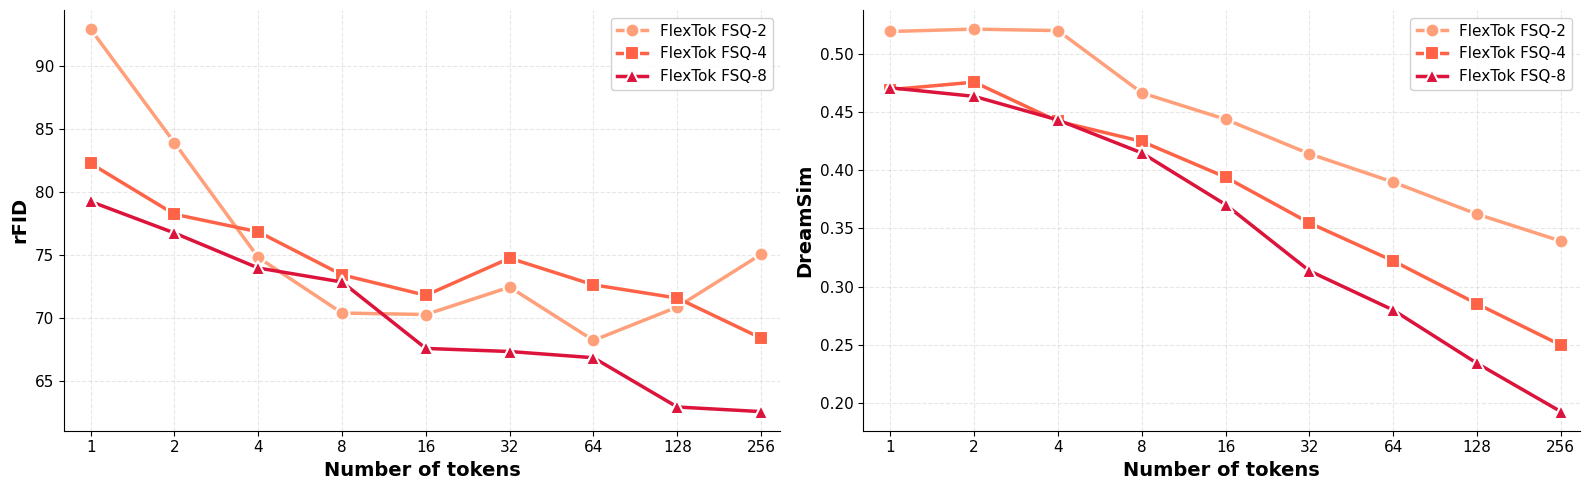


Plot saved as 'reconstruction_metrics_comparison.png'


In [23]:
# Create dual-metric plot similar to reference image
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics = ['rFID', 'DreamSim']
results_list = [rfid_results, dreamsim_results]

for idx, (ax, metric_name, results) in enumerate(zip(axes, metrics, results_list)):
    for model_config in models_config:
        model_name = model_config['name']
        if model_name == 'Original FSQ':
            continue
        model_name = model_config['name']
        scores = [results[model_name][k] for k in token_counts]
        
        ax.plot(
            token_counts,
            scores,
            marker=model_config['marker'],
            color=model_config['color'],
            linewidth=2.5,
            markersize=10,
            label=f"FlexTok {model_name}",
            markeredgewidth=1.5,
            markeredgecolor='white'
        )
    
    ax.set_xlabel('Number of tokens', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=14, fontweight='bold')
    ax.set_xscale('log', base=2)
    ax.set_xticks(token_counts)
    ax.set_xticklabels(token_counts)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, framealpha=0.9, loc='best')
    ax.set_xlim(0.8, 300)
    
    # Styling
    ax.tick_params(labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reconstruction_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'reconstruction_metrics_comparison.png'")

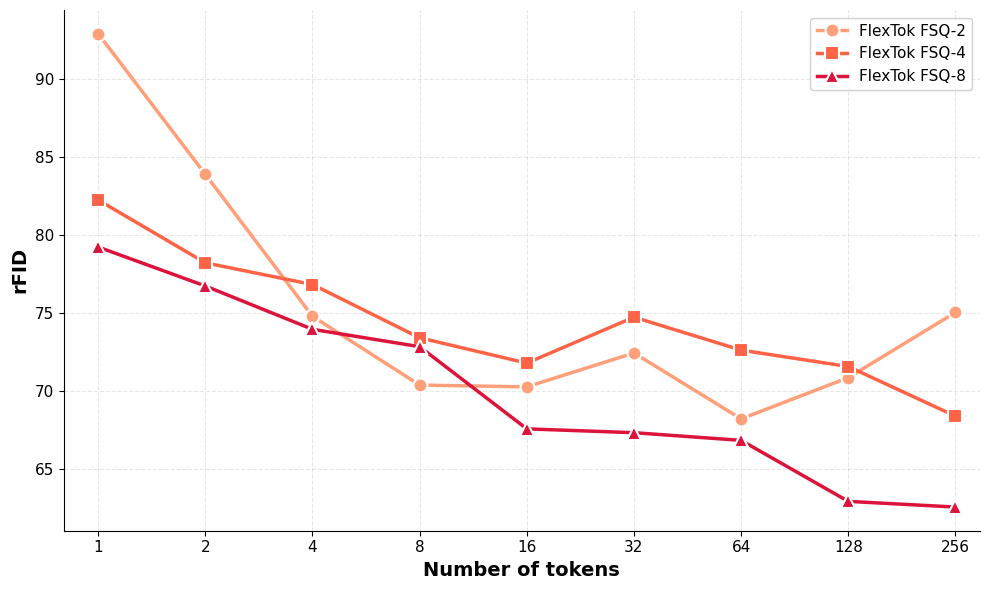


rFID plot saved as 'rfid_comparison.png'


In [25]:
# Create individual plots
# rFID plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for model_config in models_config:
    model_name = model_config['name']
    if model_name == 'Original FSQ':
        continue
    scores = [rfid_results[model_name][k] for k in token_counts]
    
    ax.plot(
        token_counts,
        scores,
        marker=model_config['marker'],
        color=model_config['color'],
        linewidth=2.5,
        markersize=10,
        label=f"FlexTok {model_name}",
        markeredgewidth=1.5,
        markeredgecolor='white'
    )

ax.set_xlabel('Number of tokens', fontsize=14, fontweight='bold')
ax.set_ylabel('rFID', fontsize=14, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_xticks(token_counts)
ax.set_xticklabels(token_counts)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, framealpha=0.9)
ax.set_xlim(0.8, 300)

# Styling
ax.tick_params(labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rfid_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nrFID plot saved as 'rfid_comparison.png'")

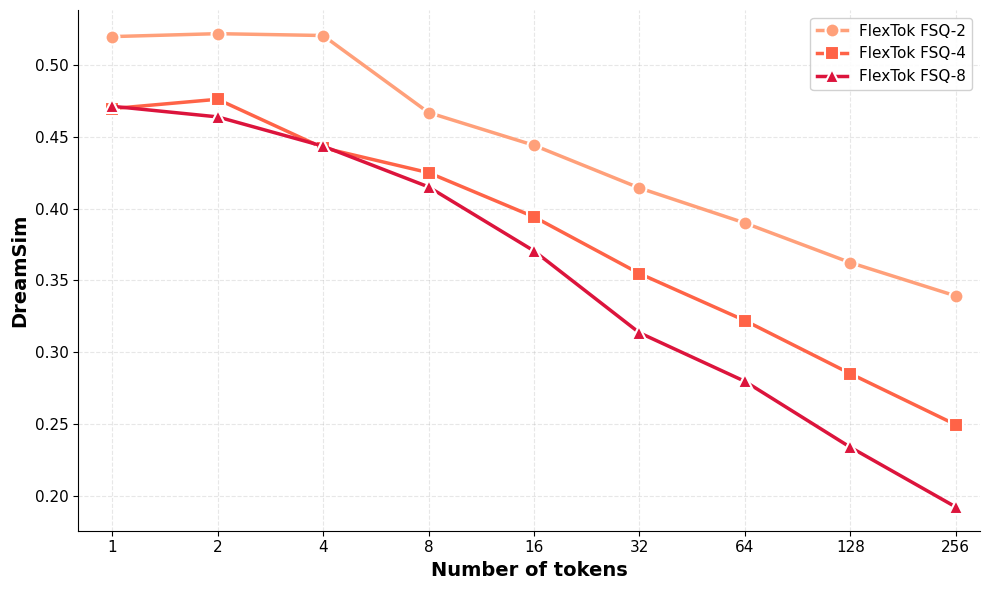


DreamSim plot saved as 'dreamsim_comparison.png'


In [26]:
# DreamSim plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for model_config in models_config:
    model_name = model_config['name']
    if model_name == 'Original FSQ':
        continue
    scores = [dreamsim_results[model_name][k] for k in token_counts]
    
    ax.plot(
        token_counts,
        scores,
        marker=model_config['marker'],
        color=model_config['color'],
        linewidth=2.5,
        markersize=10,
        label=f"FlexTok {model_name}",
        markeredgewidth=1.5,
        markeredgecolor='white'
    )

ax.set_xlabel('Number of tokens', fontsize=14, fontweight='bold')
ax.set_ylabel('DreamSim', fontsize=14, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_xticks(token_counts)
ax.set_xticklabels(token_counts)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, framealpha=0.9)
ax.set_xlim(0.8, 300)

# Styling
ax.tick_params(labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dreamsim_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDreamSim plot saved as 'dreamsim_comparison.png'")

## Save Results

In [ ]:
import json

# Save results to JSON
results_dict = {
    'token_counts': token_counts,
    'models': {}
}

for model_config in models_config:
    model_name = model_config['name']
    results_dict['models'][model_name] = {
        'rfid_scores': {str(k): rfid_results[model_name][k] for k in token_counts},
        'dreamsim_scores': {str(k): dreamsim_results[model_name][k] for k in token_counts},
        'checkpoint': model_config['ckpt_path'],
        'fsq_levels': model_config['fsq_levels']
    }

with open('reconstruction_metrics_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to 'reconstruction_metrics_results.json'")